### Embeddings: Numeric Representations of Words, Documents, Sentences, and Topics
<b>Thomas Bryan Smith</b><br>
Department of Criminal Justice and Legal Studies<br>
University of Mississippi<br>

<b>Ayan-Yue Gupta</b><br>
Behave Lab<br>
Department of Social and Political Science<br>
University of Milan<br>

### Contents
1. Viewing and Describing our Data
    - Regular Expressions
    - spaCy
2. Word Embeddings with Word2Vec
3. Document Embeddings with Doc2Vec
4. Text Embeddings with Sentence Transformers (s-BERT)
    - Sentence Embeddings
    - Contextualized Word Embeddings
    - Document Embeddings
5. Topic Embeddings with BERTopic
6. Visualizing Embeddings

### Downloading Practice Corpora

#### Import libraries

In [1]:
import requests
import re
import pandas as pd

#### Bram Stoker's Dracula

I will be using Bram Stoker's Dracula for my demonstrations.

Downloading Dracula:

In [2]:
# Project Gutenberg plain text URL for Dracula (EBook #345).
url = "https://www.gutenberg.org/cache/epub/345/pg345.txt"
    ## Update this URL if you would prefer to work with a different novel.
    
# Destination filename.
filename = "../data/dracula.txt"
    ## Update this filename with whatever book you choose.
    
# Send a GET request to download the file.
response = requests.get(url, timeout=15)
        
# Save the content as a text file with UTF-8 encoding.
with open(filename, "w", encoding="utf-8") as file:
          file.write(response.text)

Cleaning the Raw Text:

In [3]:
# Import the raw text file from the working environment
with open(filename, "r", encoding="utf-8") as file:
    text = file.read()
    
# Locate the start and end of the book.
start_marker = "of knowledge of those who made them."
end_marker = "                                THE END"
    ## These markers will need updating to match your book.
    ## You do this manually by coping the line of the text that
    ## marks the beginning and the end.
    
# Trim text down to start and end of the book.
text = text.split(start_marker)[1].split(end_marker)[0].strip()
            
# Mark paragraph breaks.
text = re.sub(r'\n{4,}', '<<<¶>>>', text)

# Remove line breaks.
text = re.sub(r'\n\s*\n', ' ', text)

# Restore paragraph breaks.
text = text.replace('<<<¶>>>', '\n\n')

# Save the cleaned text file with UTF-8 encoding.
with open(filename, "w", encoding="utf-8") as f_clean:
    f_clean.write(text)

Breaking the text into Chapters and building a Data Frame:

In [4]:
# Split text into chapter titles and chapter contents
chapters = re.split(r'(CHAPTER\s+[IVXLCDM]+)', text)

rows = []

for i in range(1, len(chapters), 2):
    chapter_title = chapters[i]
    chapter_text = chapters[i + 1].strip()

    paragraphs = [
        p.strip()
        for p in chapter_text.split('\n\n')
        if p.strip()
    ]

    for j, paragraph in enumerate(paragraphs, start=1):
        rows.append({
            "chapter": chapter_title,
            "paragraph_num": j,
            "paragraph": paragraph
        })

drac = pd.DataFrame(rows)

The above code (1) downloads the raw text file for "Dracula" directly from the Gutenberg project, (2) trims the start and the end of the book, leaving only the narrative, then (3) chapterizes the text and stores the data as a data frame for convenience. If you want to download a book to work with manually, you can do so. You simply skip (1), the first code chunk, and start with (2), the second code chunk. I have indicated which parts of the code will likely need updating.

#### Mary Wollstonecraft Shelley's Frankenstein

For the practical exercises I will assign to accompany this workshop's content, you will be working with Mary Wollstonecraft Shelley's Frankenstein! (or a book / corpus of your own choosing)

In [5]:
# Project Gutenberg plain text URL for Dracula (EBook #345).
url = "https://www.gutenberg.org/cache/epub/84/pg84.txt"
    ## Update this URL if you would prefer to work with a different novel.
    
# Destination filename.
filename = "../data/frankenstein.txt"
    ## Update this filename with whatever book you choose.
    
# Send a GET request to download the file.
response = requests.get(url, timeout=15)

# Extract the raw text from the URL request.
text = response.text

# Locate the start and end of the book.
start_marker = "embraced the gallant vessel on its course and wrecked it—thus!"
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK FRANKENSTEIN; OR, THE MODERN PROMETHEUS ***"
    ## These markers will need updating to match your book.
    ## You do this manually by coping the line of the text that
    ## marks the beginning and the end.
    
# Trim text down to start and end of the book.
text = text.split(start_marker)[1].split(end_marker)[0].strip()

# Mark paragraph breaks (4 or more consecutive CRLF sequences).
text = re.sub(r'(?:\r\n){2,}', '<<<¶>>>', text)

# Remove remaining line breaks (single or double CRLF used for line wrapping).
text = re.sub(r'(?:\r\n)+', ' ', text)

# Restore paragraph breaks.
text = text.replace('<<<¶>>>', '\n\n')

# Save the cleaned text file with UTF-8 encoding.
with open(filename, "w", encoding="utf-8", newline="\n") as f_clean:
    f_clean.write(text)
    
# Split text into chapter titles and chapter contents
chapters = re.split(r'(Chapter\s+\d+)', text)
    ## This will need revising if you opt to import your own text.

rows = []

for i in range(1, len(chapters), 2):
    chapter_title = chapters[i]
    chapter_text = chapters[i + 1].strip()

    paragraphs = [
        p.strip()
        for p in chapter_text.split('\n\n')
        if p.strip()
    ]

    for j, paragraph in enumerate(paragraphs, start=1):
        rows.append({
            "chapter": chapter_title,
            "paragraph_num": j,
            "paragraph": paragraph
        })

frnk = pd.DataFrame(rows)

### 1. Viewing and Describing our Data

#### Regular Expressions

In [6]:
drac

,chapter,paragraph_num,paragraph
0,CHAPTER I,1,JONATHAN HARKER’S JOURNAL
1,CHAPTER I,2,(_Kept in shorthand._)
2,CHAPTER I,3,"_3 May. Bistritz._--Left Munich at 8:35 P. M.,..."
3,CHAPTER I,4,"We left in pretty good time, and came after ni..."
4,CHAPTER I,5,Having had some time at my disposal when in Lo...
...,...,...,...
2114,CHAPTER XXVII,76,Seven years ago we all went through the flames...
2115,CHAPTER XXVII,77,In the summer of this year we made a journey t...
2116,CHAPTER XXVII,78,When we got home we were talking of the old ti...
2117,CHAPTER XXVII,79,“We want no proofs; we ask none to believe us!...


Lets get a sentence, word, and character counts per paragraph:

In [7]:
drac['sentence_count'] = drac['paragraph'].str.count(r'[\w][\.!\?]')
drac['word_count'] = drac['paragraph'].str.split().str.len()
drac['character_count'] = drac['paragraph'].str.len()
drac

,chapter,paragraph_num,paragraph,sentence_count,word_count,character_count
0,CHAPTER I,1,JONATHAN HARKER’S JOURNAL,0,3,25
1,CHAPTER I,2,(_Kept in shorthand._),1,3,22
2,CHAPTER I,3,"_3 May. Bistritz._--Left Munich at 8:35 P. M.,...",8,117,626
3,CHAPTER I,4,"We left in pretty good time, and came after ni...",7,103,537
4,CHAPTER I,5,Having had some time at my disposal when in Lo...,4,173,934
...,...,...,...,...,...,...
2114,CHAPTER XXVII,76,Seven years ago we all went through the flames...,4,88,443
2115,CHAPTER XXVII,77,In the summer of this year we made a journey t...,4,79,410
2116,CHAPTER XXVII,78,When we got home we were talking of the old ti...,4,126,661
2117,CHAPTER XXVII,79,“We want no proofs; we ask none to believe us!...,3,52,262


In [8]:
print("Dracula's main text consists of approximately", 
      len(drac), 
      "paragraphs,",
      drac['sentence_count'].sum(),
      "sentences,",
      drac['word_count'].sum(),
      "words, and",
      drac['character_count'].sum(),
      "characters.")

Dracula's main text consists of approximately 2119 paragraphs, 9250 sentences, 160756 words, and 836090 characters.


Looking at the first few pages of the data frame, there are quite a few paragraphs with very few (or no) sentences. Let's remove these from the data.

In [9]:
# Index the data frame
drac = drac[drac['sentence_count'] >= 2]

Now let's visualize the distribution of word counts:

In [10]:
# Load the 'Counter' function from the collections library
from collections import Counter

# Generate word counts using a `for` loop
word_counts = Counter()
for paragraph in drac['paragraph']:
    words = paragraph.lower().split()
    word_counts.update(words)
    
word_counts.most_common(10)

[('the', 7484),
 ('and', 5466),
 ('i', 4294),
 ('to', 4241),
 ('of', 3452),
 ('a', 2751),
 ('he', 2346),
 ('in', 2304),
 ('that', 2271),
 ('was', 1727)]

That's a lot of stopwords, let's remove them using ntlk's stopwords dictionary:

In [11]:
# Load the nltk library
import nltk

# Download, load, and extract English stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords = set(stopwords.words('english'))

# Filter the word_counts object
filtered_words = Counter({word: count for word, count in word_counts.items() if word not in stopwords})

# Return most common
filtered_words.most_common(10)

[nltk_data] Downloading package stopwords to C:\Users\Tom
[nltk_data]     Smith\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('could', 440),
 ('must', 417),
 ('would', 395),
 ('one', 394),
 ('shall', 394),
 ('may', 355),
 ('see', 323),
 ('know', 290),
 ('us', 281),
 ('came', 276)]

Still not great if we want to understand the substance of the text.

#### SpaCy

As a final step, let's work with the spaCy library to do some light pre-processing, then generate word counts for nouns and adjectives exclusively:

In [12]:
# Load the spaCy library
import spacy
from spacy.cli import download

# Load the en_core_web_sm pipeline
download("en_core_web_sm") # ← only need to run this once
nlp = spacy.load("en_core_web_sm")

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Working with spaCy across multiiple paragraphs can be a little tricky because we have words nested within documents (paragraphs). 

So, to make things easier, we can build a simple function:

In [13]:
def get_words_by_pos(text, target_pos = {"NOUN", "ADJ", "PROPN"}):
    # Run the target document through the downloaded nlp pipeline
    doc = nlp(text)
    # Return the token text if its part-of-speech tag matches our targets
    return [token.lemma_ for token in doc if token.pos_ in target_pos]

Then we can apply that function to our paragraphs, and generate word counts:
- <i>Note that this code can take a minute or two to run, depending on how you have configured Python, the specifications of your device, etc.</i>

In [14]:
drac['paragraph'].apply(get_words_by_pos, 
                        target_pos = {"PROPN"}).explode().value_counts()

paragraph
Van              278
Helsing          277
Lucy             258
Mina             181
Jonathan         175
                ... 
August._--I        1
Lighthouse         1
August._--Joy      1
S.--My             1
gypsy              1
Name: count, Length: 1004, dtype: int64

This is <i>much</i> more informative!

The benefit of using spaCy to describe your data is that it gives you access to a much wider variety of NLP tools with which to understand the data. The `en_core_web_sm` pipeline you loaded actually does much more than just part-of-speech tagging (identifying nouns, adjectives, etc.). 

The default, <i>unmodified</i> pipeline does the following:
1. Tokenization with tok2vec
2. Part-of-Speech Tagging
3. Dependency Parsing
4. Lemmatization (conversion of words into their root words)
5. Rules-based corrections to all of the above

However, it can do so much more, if your project would benefit from it!

#### Exercise #1
1. Generate paragraph, sentence, word, and character counts for Mary Shelley's Frankenstein. 
2. Use the `get_words_by_pos()` function I have provided to extract the frequency distribution for one or more of nouns (NOUN), adjectives (ADJ), pronouns (PRON), and proper nounds (PROPN).

### 2. Word Embeddings with Word2Vec

In the below code chunk, we have a simplified example of the steps you would take to generate word embeddings based on a set of documents (in our case paragraphs) stored in a data frame object.

As you can see, it is actually a relatively simple process—even if working with the embeddings themselves is anything but!

One thing to note about this example is that I am only using the `simple_preprocess()` function from `gensim.utils` when preparing the data. Generally, when working with real-world, unformatted data you will need to build a much more involved preprocessing pipeline. I would advise using spaCy if you want to put your corpus through more thorough preprocessing steps.

In [15]:
# Load the gensim library
import gensim
from gensim.utils import simple_preprocess
from gensim.models import Word2Vec

# Tokenize the paragraphs ready for word2vec
drac['tokens'] = drac['paragraph'].apply(lambda x: simple_preprocess(x))

# Extract tokenized paragraphs as a list variable
tokenized_paragraphs = drac['tokens'].tolist()

# Fit word2vec to the tokenized paragraphs
model = Word2Vec(sentences = tokenized_paragraphs,
                 vector_size = 100,
                 window = 5,
                 min_count = 1,
                 workers = 4)

# Extract the words and corresponding word embeddings from the model
words = model.wv.index_to_key
embeddings = [model.wv[word] for word in words]

# Create a new data frame containing the words and their embedding vectors
word_embeddings = pd.DataFrame({
    'word': words,
    'embedding': embeddings
})

# View the data frame
word_embeddings

C:\Users\Tom Smith\AppData\Local\Temp\ipykernel_27336\4171339266.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drac['tokens'] = drac['paragraph'].apply(lambda x: simple_preprocess(x))


,word,embedding
0,the,"[-0.4552289, 0.90726143, 0.28258258, -0.148158..."
1,and,"[-0.3611912, 0.88820606, 0.16042466, -0.112183..."
2,to,"[-0.11091065, 0.680979, -0.11937072, -0.129831..."
3,of,"[-0.2989376, 0.9584489, 0.21549009, -0.3152219..."
4,he,"[-0.3701181, 0.72607946, 0.0017700727, -0.0621..."
...,...,...
9032,shield,"[0.004395499, -0.0038574738, -0.0066326167, -0..."
9033,laziness,"[0.0037034359, 0.018206855, 0.00534947, 0.0026..."
9034,abed,"[-0.0104009975, 0.0032719786, -0.010061254, -0..."
9035,impatiently,"[-0.004183658, -0.00084817887, 0.004592773, -0..."


That's all there is to it! Generating embeddings is actually surprisingly simple! 

However, generating <i>good</i> embeddings is difficult, and will require that you take time to ensure your hyperparameters (vector size, window, min_count, etc.) are properly tuned, the data are properly preprocessed, and so on.

So, use this code chunk as a <i>foundation</i> for your projects—not as the final product.

### 3. Document Embeddings with Doc2Vec

As in the previous section, below is a simplified code chunk generating document embeddings with doc2vec. Note that it only loads new functions and libraries that have not already been loaded previously in this notebook. Moreover, it assumes you have already generated the 'tokens' column for the data frame using the `simple_preprocess()` function from `gensim.utils`. If applying this in your own projects without having run the corresponding code from the word2vec code chunk, you will need to add preprocessing code (or, better yet, build a more robust preprocessing pipeline that is tailored to your data!)

In [16]:
# Load any functions we are currently missing
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

# We have already preprocessed the data as part of word2vec
# Check for the existence of the 'token' column
print("Data have been preprocessed and 'tokens' column exists:", 'tokens' in drac.columns)

# Extract tagged paragraphs
tagged_paragraphs = [
    TaggedDocument(words = row['tokens'], 
                   tags = [str(index)]) 
    for index, row in drac.iterrows()
]

# Fit doc2vec to the tagged paragraphs
## Set hyperparameters
model = Doc2Vec(vector_size = 100,
                min_count=1,
                window=5,
                epochs=20,
                workers=4)
## Build model vocabulary
model.build_vocab(tagged_paragraphs)
## Train the model
model.train(tagged_paragraphs,
            total_examples = model.corpus_count,
            epochs = model.epochs)

# Extract document embeddings, add them into the `drac` data frame
drac['d2v_embedding'] = drac.index.map(lambda idx: model.dv[str(idx)])

# View the data frame
drac

Data have been preprocessed and 'tokens' column exists: True


C:\Users\Tom Smith\AppData\Local\Temp\ipykernel_27336\2729437636.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drac['d2v_embedding'] = drac.index.map(lambda idx: model.dv[str(idx)])


,chapter,paragraph_num,paragraph,sentence_count,word_count,character_count,tokens,d2v_embedding
2,CHAPTER I,3,"_3 May. Bistritz._--Left Munich at 8:35 P. M.,...",8,117,626,"[may, bistritz, left, munich, at, on, st, may,...","[0.08099953, 0.0018053923, 0.29262376, 0.31548..."
3,CHAPTER I,4,"We left in pretty good time, and came after ni...",7,103,537,"[we, left, in, pretty, good, time, and, came, ...","[-0.006255816, 0.043859888, 0.06699859, 0.0664..."
4,CHAPTER I,5,Having had some time at my disposal when in Lo...,4,173,934,"[having, had, some, time, at, my, disposal, wh...","[0.37589887, 0.0027206552, 0.15635957, 0.00727..."
5,CHAPTER I,6,In the population of Transylvania there are fo...,6,122,674,"[in, the, population, of, transylvania, there,...","[0.17613152, 0.07940888, 0.18638702, -0.057601..."
6,CHAPTER I,7,"I did not sleep well, though my bed was comfor...",9,192,993,"[did, not, sleep, well, though, my, bed, was, ...","[-0.016980838, -0.044238254, 0.08527523, 0.282..."
...,...,...,...,...,...,...,...,...
2111,CHAPTER XXVII,73,“Now God be thanked that all has not been in v...,4,26,133,"[now, god, be, thanked, that, all, has, not, b...","[0.057835158, -0.007105389, -0.011476463, -0.0..."
2114,CHAPTER XXVII,76,Seven years ago we all went through the flames...,4,88,443,"[seven, years, ago, we, all, went, through, th...","[0.19633338, 0.077203915, 0.08260285, -0.16641..."
2115,CHAPTER XXVII,77,In the summer of this year we made a journey t...,4,79,410,"[in, the, summer, of, this, year, we, made, jo...","[0.19130823, -0.022178845, 0.09632052, 0.06488..."
2116,CHAPTER XXVII,78,When we got home we were talking of the old ti...,4,126,661,"[when, we, got, home, we, were, talking, of, t...","[0.15923062, 0.18872245, 0.051462784, 6.573611..."


#### Exercise #2 
- Fit word2vec and doc2vec models to the Frankenstein corpus.
- Build a word embeddings data frame derived of the word2vec model.
- Introduce a `doc2vec embeddings` column to the Frankenstein data frame derived of the doc2vec model.

### 4. Text Embeddings with Sentence Transformers (s-BERT)

#### Sentence Embeddings

In [17]:
# Load the SentenceTransfomer function from the sentence_transformers library
from sentence_transformers import SentenceTransformer

# Use the spacy `sentencizer` to break the paragraphs down into sentences
## Load an empty english-language spacy NLP pipeline
nlp = spacy.blank('en')
## Add the sentencizer to the NLP pipeline
nlp.add_pipe('sentencizer')

# Apply the sentencizer to the data frame
sentences = []
for paragraph in drac["paragraph"]:
    # Individually feed each paragraph through the nlp pipeline
    proc_para = nlp(paragraph)
    # Extract each sentence string and remove any leading/trailing whitespace
    for sent in proc_para.sents:
        sentences.append(sent.text.strip())
        
# Initiate a sentence transformer model to serve as your starting checkpoint
model = SentenceTransformer('all-MiniLM-L6-v2')
## This is where you have the option to load a more substantial transformer model.
## If you wish to incorporate a 'true' compact LLM, you can find a vast collection
## of models on HuggingFace.
## We will stick with `all-MiniLM-L6-v2` because we need the model to run quickly.

# Encode the sentences based on the pre-trained embeddings in `all-MiniLM-L6-v2`
embeddings = model.encode(sentences)

# Build a new data frame containing sentence embeddings
sentence_embeddings = pd.DataFrame({
    'sentence': sentences,
    'embedding': embeddings.tolist()
})

# View the data frame
sentence_embeddings

C:\Users\Tom Smith\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,sentence,embedding
0,_3 May.,"[-0.017625415697693825, -0.09034617990255356, ..."
1,"Bistritz._--Left Munich at 8:35 P. M., on 1st ...","[0.03833450749516487, 0.04369333013892174, -0...."
2,"Buda-Pesth seems a wonderful place, from the g...","[0.04032786563038826, 0.05151708796620369, -0...."
3,"I feared to go very far from the station, as w...","[0.027587156742811203, 0.0210905559360981, -0...."
4,The impression I had was that we were leaving ...,"[0.03974362835288048, 0.07299146801233292, 0.0..."
...,...,...
8487,"We could hardly ask any one, even did we wish ...","[-0.04010168835520744, 0.10756456106901169, 0...."
8488,"Van Helsing summed it all up as he said, with ...","[-0.025226833298802376, 0.11044438183307648, 0..."
8489,“We want no proofs; we ask none to believe us!,"[-0.08513062447309494, 0.07338593155145645, -0..."
8490,This boy will some day know what a brave and g...,"[-0.028687691316008568, 0.1066562607884407, -0..."


##### Fine-Tuning s-BERT Models

It is important to note that the encoding of these sentences are based solely on the pre-trained s-BERT model we initialized with the `SentenceTransformer()` function. Our book, Dracula, had absolutely no influence on the embeddings. This means that the sentence embeddings are based on the generalized 'understanding' of language learned by the `all-MiniLM-L6-v2` model, and has not learned anything new from our good friend Bram Stoker.

This can be desirable, as the data to which you have access might be very limited (as in this case, where we only have a single book and a few thousand sentences). However, you <i>can</i> also <b>further pre-train</b> (aka 'fine-tune') the `all-MiniLM-L6-v2` model such that the sentence embeddings are updated based on your corpus.

Note that the following code does not use robust hyperparameters (you typically want a batch size between 32 and 256, and up to 5 epochs [higher you set these values, the more computationally expensive your training will be]), or a sufficiently large dataset.

In [18]:
# Load the SentenceTransfomer function from the sentence_transformers library
from datasets import Dataset
from sentence_transformers import (
    SentenceTransformer, 
    SentenceTransformerTrainer, 
    SentenceTransformerTrainingArguments
)
from sentence_transformers.losses import MultipleNegativesRankingLoss

# Use the spacy `sentencizer` to break the paragraphs down into sentences
## Load an empty english-language spacy NLP pipeline
nlp = spacy.blank('en')
## Add the sentencizer to the NLP pipeline
nlp.add_pipe('sentencizer')

# Apply the sentencizer to the data frame
sentences = []
for paragraph in drac["paragraph"]:
    # Individually feed each paragraph through the nlp pipeline
    proc_para = nlp(paragraph)
    # Extract each sentence string and remove any leading/trailing whitespace
    for sent in proc_para.sents:
        sentences.append(sent.text.strip())
        
# ===============================================================================     
# Fine-tuning begins--
## Initiate a sentence transformer model to serve as your starting checkpoint
model = SentenceTransformer('all-MiniLM-L6-v2')

## Prepare the training data
train_dataset = Dataset.from_dict({
    "anchor": sentences[:-1],
    "positive": sentences[1:]
})

## Initialize the loss function
train_loss = MultipleNegativesRankingLoss(model)

## Set hyperparameters
training_args = SentenceTransformerTrainingArguments(
    output_dir = "fine_tuned_minilm",
    num_train_epochs = 1,                   # Set based on GPU specs.
    per_device_train_batch_size = 16,       # Set based on GPU specs.
    learning_rate = 2e-5,
    weight_decay = 0.01,
    logging_steps = 10,
    save_strategy = "no",                    # We aren't saving any checkpoints
    logging_strategy = "no",
    report_to = "tensorboard"
)

# Initialize the trainer
trainer = SentenceTransformerTrainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    loss = train_loss
)

# Further pre-train the `all-MiniLM-L6-v2` model
trainer.train()

# Fine-tuning ends--
# ===============================================================================

# Encode the sentences based on the fine-tuned model
embeddings = model.encode(sentences)

# Build a new data frame containing sentence embeddings
sentence_embeddings = pd.DataFrame({
    'sentence': sentences,
    'embedding': embeddings.tolist()
})

# View the data frame
sentence_embeddings

Step,Training Loss


,sentence,embedding
0,_3 May.,"[0.01997741125524044, -0.059576839208602905, 0..."
1,"Bistritz._--Left Munich at 8:35 P. M., on 1st ...","[0.05611107498407364, 0.040252938866615295, 0...."
2,"Buda-Pesth seems a wonderful place, from the g...","[0.06844675540924072, 0.028298169374465942, 0...."
3,"I feared to go very far from the station, as w...","[0.051377881318330765, 0.052429284900426865, 0..."
4,The impression I had was that we were leaving ...,"[0.06018901616334915, 0.08269312232732773, 0.0..."
...,...,...
8487,"We could hardly ask any one, even did we wish ...","[0.018185660243034363, 0.10421591252088547, 0...."
8488,"Van Helsing summed it all up as he said, with ...","[-0.003757436526939273, 0.10851110517978668, 0..."
8489,“We want no proofs; we ask none to believe us!,"[-0.04382488504052162, 0.0726211816072464, -0...."
8490,This boy will some day know what a brave and g...,"[0.029163343831896782, 0.07789260894060135, 0...."


Due to the option `report_to = "tensorboard"`, the training loss data will be output to a tensorboard by the name 'fine_tuned_minilm'. This will allow you to view the loss curves later (or even during the training), allowing you to run diagnostics.

Your TensorBoard will be hosted here for as long as the next code chunk continues running: http://localhost:6006

In [19]:
# Host the tensorboard locally
# !tensorboard --logdir fine_tuned_minilm

Further pretraining s-BERT models is complex—too complex to cover in this workshop. If you want to take this route (to ensure that your embeddings better reflect specialized semantics associated with the focal corpus), then you will need to learn how to effectively fine-tune your s-BERT model.

#### Document Embeddings

We have already initialized (and fine-tuned, if necessary) the s-BERT model of our choosing. We can use this model to generate both contextualized word embeddings and document (paragraph) embeddings. These embeddings inherit many of the benefits of s-BERT, making them a more robust choice than word2vec and doc2vec.

Document embeddings are a little easier to generate than contextualized word embeddings using s-BERT models, so we will focus primarily on s-BERT document embeddings. This is because The process is fundamentally the same as when generating sentence embeddings. You simply encode the documents as a whole without sentencizing them.

The only problem is that BERT models have a maximum sequence length (in the case of all-MiniLM-L6-v2, 256 tokens), and paragraphs tend to exceed that sequence length. So, you have to chunk the paragraphs first (so that they are equal to or less than 256 tokens), then average across the chunked embeddings.

After encoding, they can be assigned back to the data frame, as with doc2vec.

In [20]:
# load missing library
import numpy as np

# Define a function that splits the text into tokens, 
# and then forms appropriately sized chunks
def chunk_text(text, chunk_size=200):
    words = text.split()

    return [
        " ".join(words[i:i+chunk_size])
        for i in range(0, len(words), chunk_size)
    ]
    
# Create an empty list to store embeddings
doc_embeddings = []

# Chunk-then-Encode-then-Average
for doc in drac["paragraph"]:

    # Chunk
    chunks = chunk_text(doc)

    # Encode
    chunk_embeddings = model.encode(chunks)

    # Average
    doc_embedding = np.mean(chunk_embeddings, axis=0)
    
    # Append the pooled embeddings onto the empty list
    doc_embeddings.append(doc_embedding)

# Append the s-BERT document embeddings onto the existing data frame
drac["sbert_embedding"] = [emb.tolist() for emb in doc_embeddings]

# View the data frame
drac

C:\Users\Tom Smith\AppData\Local\Temp\ipykernel_27336\1585193649.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drac["sbert_embedding"] = [emb.tolist() for emb in doc_embeddings]


,chapter,paragraph_num,paragraph,sentence_count,word_count,character_count,tokens,d2v_embedding,sbert_embedding
2,CHAPTER I,3,"_3 May. Bistritz._--Left Munich at 8:35 P. M.,...",8,117,626,"[may, bistritz, left, munich, at, on, st, may,...","[0.08099953, 0.0018053923, 0.29262376, 0.31548...","[0.07188298553228378, 0.08184739947319031, 0.0..."
3,CHAPTER I,4,"We left in pretty good time, and came after ni...",7,103,537,"[we, left, in, pretty, good, time, and, came, ...","[-0.006255816, 0.043859888, 0.06699859, 0.0664...","[0.012768947519361973, 0.04110361635684967, 0...."
4,CHAPTER I,5,Having had some time at my disposal when in Lo...,4,173,934,"[having, had, some, time, at, my, disposal, wh...","[0.37589887, 0.0027206552, 0.15635957, 0.00727...","[0.10501863807439804, 0.022926656529307365, 0...."
5,CHAPTER I,6,In the population of Transylvania there are fo...,6,122,674,"[in, the, population, of, transylvania, there,...","[0.17613152, 0.07940888, 0.18638702, -0.057601...","[0.04081111028790474, 0.011473629623651505, 0...."
6,CHAPTER I,7,"I did not sleep well, though my bed was comfor...",9,192,993,"[did, not, sleep, well, though, my, bed, was, ...","[-0.016980838, -0.044238254, 0.08527523, 0.282...","[0.025862080976366997, 0.003588044550269842, 0..."
...,...,...,...,...,...,...,...,...,...
2111,CHAPTER XXVII,73,“Now God be thanked that all has not been in v...,4,26,133,"[now, god, be, thanked, that, all, has, not, b...","[0.057835158, -0.007105389, -0.011476463, -0.0...","[-0.03856448829174042, 0.1047004908323288, 0.0..."
2114,CHAPTER XXVII,76,Seven years ago we all went through the flames...,4,88,443,"[seven, years, ago, we, all, went, through, th...","[0.19633338, 0.077203915, 0.08260285, -0.16641...","[0.0035664374008774757, 0.05009951442480087, 0..."
2115,CHAPTER XXVII,77,In the summer of this year we made a journey t...,4,79,410,"[in, the, summer, of, this, year, we, made, jo...","[0.19130823, -0.022178845, 0.09632052, 0.06488...","[0.09395849704742432, 0.06313446909189224, 0.0..."
2116,CHAPTER XXVII,78,When we got home we were talking of the old ti...,4,126,661,"[when, we, got, home, we, were, talking, of, t...","[0.15923062, 0.18872245, 0.051462784, 6.573611...","[-0.007118001580238342, 0.07214561104774475, 0..."


#### Contextualized Word Embeddings

The process for generating contextualized sentence embeddings is complicated, requiring that you work with the model within torch, so you can extract token embeddings directly from the encoder layers of the model and them map them onto the words in your corpus. So, I will not be going into detail about this process - I merely wanted to demonstrate how you might go about it.

In [21]:
# Load missing functions and libraries
from transformers import AutoTokenizer, AutoModel
import torch

# Load the tokenizer into the environment via the transformer library
tokenizer = AutoTokenizer.from_pretrained(
    "sentence-transformers/all-MiniLM-L6-v2"
)

# Load the model into the environment via the transformer library
model = AutoModel.from_pretrained(
    "sentence-transformers/all-MiniLM-L6-v2"
)

# Create an empty list to store embeddings
word_embeddings = []

# Encode the sentences stored in the sentences variable
for sentence in sentences:

    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True
    )

    with torch.no_grad():
        outputs = model(**inputs)

    tokens = tokenizer.convert_ids_to_tokens(
        inputs["input_ids"][0]
    )

    for token, embedding in zip(
        tokens,
        outputs.last_hidden_state[0]
    ):

        word_embeddings.append({
            "sentence": sentence,
            "token": token,
            "embedding": embedding.numpy()
        })

# Convert the output into a data frame
context_word_embeddings = pd.DataFrame(word_embeddings)

# View the data frame
context_word_embeddings

,sentence,token,embedding
0,_3 May.,[CLS],"[-0.0081054885, -0.38689822, 0.11853396, -0.19..."
1,_3 May.,_,"[-0.368865, -0.73289436, 0.28613436, -0.092757..."
2,_3 May.,3,"[-0.076276794, -0.7600289, 0.1314987, -0.44011..."
3,_3 May.,may,"[0.045958314, -0.41971236, 0.7801741, -0.12672..."
4,_3 May.,.,"[-0.13196811, -0.080643326, -0.39844632, 0.529..."
...,...,...,...
210941,Already he knows her sweetness and loving care...,her,"[0.42492408, -0.5273366, 0.20689662, 0.3820175..."
210942,Already he knows her sweetness and loving care...,sake,"[-0.010956364, 0.25059092, 0.1462605, 0.116748..."
210943,Already he knows her sweetness and loving care...,.,"[0.0064439178, 0.07776287, 0.26933852, 0.27257..."
210944,Already he knows her sweetness and loving care...,”,"[-0.18369816, 0.33263493, 0.30191377, -0.01065..."


### 5. Topic Embeddings with BERTopic

In this demonstration, we are going to skip the document chunking because the majority of paragraphs in Dracula are within the acceptable sequence length for `all-MiniLM-L6-v2`. Just keep in mind that BERTopic will perform better on larger documents if they are chunked before you fit the model.

In [22]:
# Import the missing libraries
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

# Initiate a sentence transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Initialize the vectorizer model
vectorizer_model = CountVectorizer(stop_words='english')

# Extract paragraphs from data frame
paragraphs = drac['paragraph'].tolist()

# Encode the document chunks
embeddings = model.encode(paragraphs, batch_size=64, show_progress_bar=True)

# Set the hyperparameters for UMAP
umap_model = UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine'
)

# Set the hyperparameters for HDBSCAN
hdbscan_model = HDBSCAN(
    min_samples=2,
    min_cluster_size=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# Set the hyperparameters for BERTopic
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    calculate_probabilities=False,
    verbose=True,
    nr_topics="auto"
)

# Fit the BERTopic Model
topics, _ = topic_model.fit_transform(paragraphs, embeddings)

# Describe the model
topic_info = topic_model.get_topic_info()

# View the data frame
topic_info

Batches: 100%|██████████| 23/23 [00:02<00:00, 11.06it/s]
2026-06-19 05:55:03,019 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-19 05:55:48,869 - BERTopic - Dimensionality - Completed ✓
2026-06-19 05:55:48,873 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-19 05:55:49,040 - BERTopic - Cluster - Completed ✓
2026-06-19 05:55:49,043 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-19 05:55:49,354 - BERTopic - Representation - Completed ✓
2026-06-19 05:55:49,356 - BERTopic - Topic reduction - Reducing number of topics
2026-06-19 05:55:49,402 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-19 05:55:49,721 - BERTopic - Representation - Completed ✓
2026-06-19 05:55:49,726 - BERTopic - Topic reduction - Reduced number of topics from 95 to 32


,Topic,Count,Name,Representation,Representative_Docs
0,-1,313,-1_shall_said_know_van,"[shall, said, know, van, think, helsing, time,...",[“His red eyes again! They are just the same.”...
1,0,768,0_said_shall_know_van,"[said, shall, know, van, helsing, time, lucy, ...","[“Because it is a part of the terrible story, ..."
2,1,41,1_driver_horses_snow_swept,"[driver, horses, snow, swept, great, began, wo...",[Then a dog began to howl somewhere in a farmh...
3,2,36,2_house_london_piccadilly_boxes,"[house, london, piccadilly, boxes, billington,...","[“I’m the depity,” he answered. I saw at once ..."
4,3,35,3_ship_mate_fog_captain,"[ship, mate, fog, captain, man, men, sea, box,...",[“No one knew where he went ‘or bloomin’ well ...
5,4,29,4_sewards_diary_dr_diarycontinued,"[sewards, diary, dr, diarycontinued, portmante...","[_Dr. Seward’s Diary._, DR. SEWARD’S DIARY--_c..."
6,5,17,5_bersicker_lies_wolf_dont,"[bersicker, lies, wolf, dont, thats, says, wol...","[“‘No,’ says he, ‘not exactly in the business,..."
7,6,13,6_souls_life_want_dont,"[souls, life, want, dont, soul, use, said, oh,...","[“I don’t want any souls, indeed, indeed! I do..."
8,7,13,7_flies_spiders_like_press,"[flies, spiders, like, press, big, wings, dont...","[“And the flies?” I said., “By making them hap..."
9,8,13,8_dracula_country_transylvania_count,"[dracula, country, transylvania, count, spoke,...",[_Midnight._--I have had a long talk with the ...


#### Visualizing BERTopic

##### Intertopic Distance Map

In [23]:
topic_model.visualize_topics()

##### Topic Barchart

In [24]:
topic_model.visualize_barchart()

##### Hierarchical Topic Clustering

In [25]:
topic_model.visualize_hierarchy()

##### Topic Heatmap

In [26]:
topic_model.visualize_heatmap()

##### Topics-over-Time

In [35]:
chapters = drac['chapter'].ne(drac['chapter'].shift()).cumsum()
topics_over_time = topic_model.topics_over_time(paragraphs, chapters.to_list())
topic_model.visualize_topics_over_time(topics_over_time)

27it [00:01, 23.36it/s]


Exercise #3: Fit a BERTopic model for the practice dataset.

#### Exercise #3 
- Fit a BERTopic model to the Frankenstein corpus (use any hyperparameters and options you would like).
- Visualize the topics from the fitted model.
- Fit the topics-over-time model, visualize the results.

#### Export Topic Embeddings

In [ ]:
# Extract the topic embeddings
topic_embeddings = topic_model.topic_embeddings_

# Extract the topic labels / IDs
topic_labels = list(topic_model.topic_labels_.keys())

# Build the data frame
topic_embeddings = pd.DataFrame({
    'topic': topic_labels,
    'embedding': topic_embeddings.tolist()
})

# View the data frame
topic_embeddings

##### Append topic embeddings to topic info data frame

In [ ]:
topic_info = pd.merge(topic_info, topic_embeddings, left_on="Topic", right_on="topic", how="inner")

### 6. Visualizing Embeddings

Extract document info from the BERTopic model. This will be used to colour code the points on the scatter plot.

In [36]:
# Extract document info
document_info = topic_model.get_document_info(drac['paragraph'])

Reduce the dimensionality of the embeddings using UMAP.

In [37]:
# Extract embeddings from the data frame
embeddings = np.stack(drac['sbert_embedding'].values)

# Initialize UMAP
reducer = UMAP(n_components=2, 
               n_neighbors=15, 
               min_dist=0.1)

# Fit and transform the embeddings to flatten into 2D
reduced_embeddings = reducer.fit_transform(embeddings)

Visualizing the 2-dimensional embeddings.

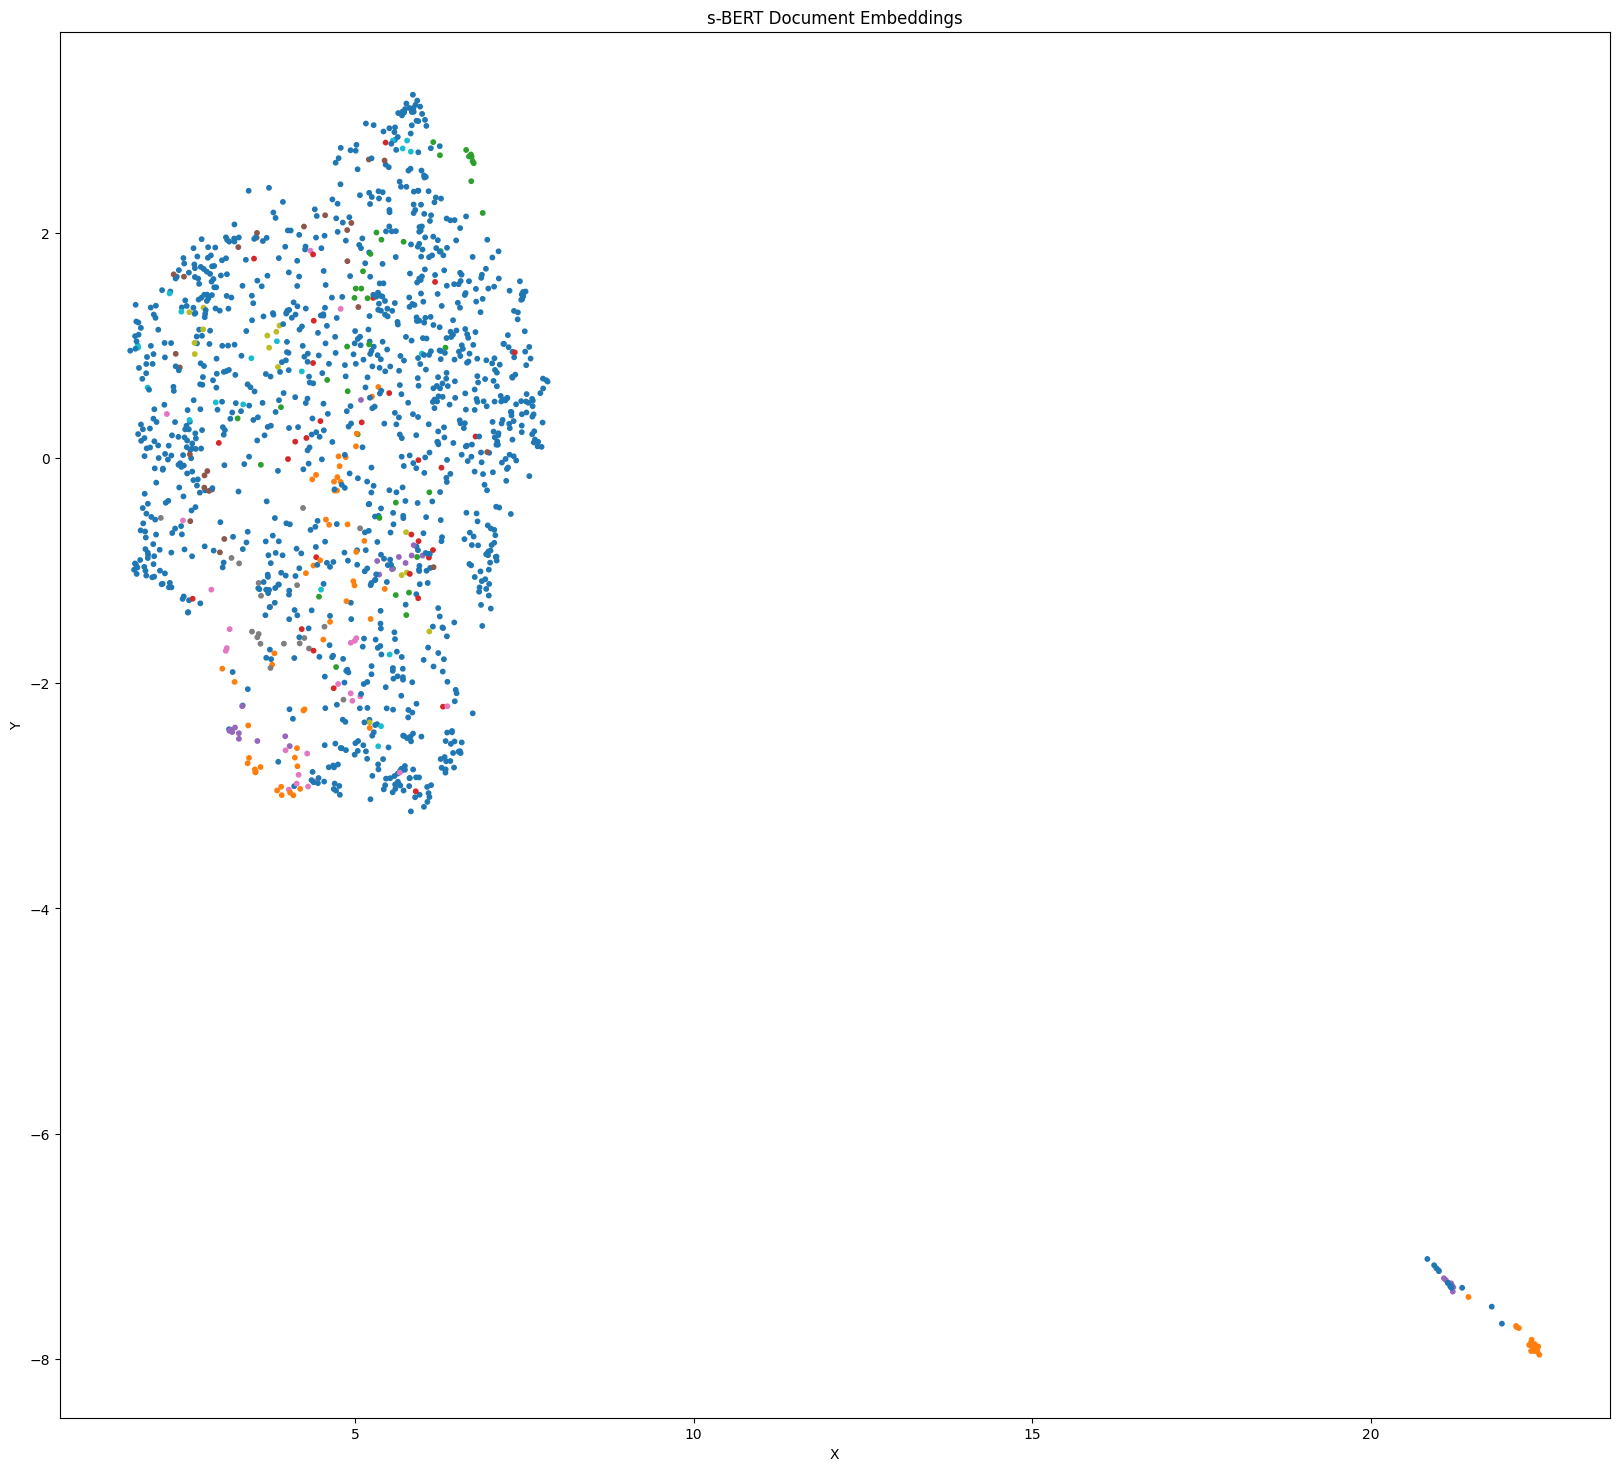

In [38]:
# Import matplotlib
import matplotlib.pyplot as plt

# Extract the x and y coordinates 
# from the reduced embeddings
x = [x[0] for x in reduced_embeddings]
y = [y[1] for y in reduced_embeddings]

# Create color codes based on topic IDs
color_codes = pd.Categorical(document_info['Topic']).codes

# Set size of the plot
plt.figure(figsize=(20, 18))

# Create the scatter plot
plt.scatter(x, y,  
            c=color_codes,
            cmap='tab10',
            marker='o', s = 10)

# Add axis title
plt.title('s-BERT Document Embeddings')
plt.xlabel('X')
plt.ylabel('Y')

# Display the plot
plt.show()

#### Exercise 4
- Visualize any set of embeddings generated as part of the previous exercises.

### MIT License

Copyright (c) 2026 Thomas Bryan Smith

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.